In [1]:
# Verify the hardware
!nvidia-smi

Wed Mar 25 00:03:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   71C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Remove previous folders in content if any
# !rm -rf /content/test_runs /content/synthetic_dataset /content/synthetic_dataset.zip /content/dataset.yaml

In [3]:
# Mount drive & ingest dataset
from google.colab import drive

drive.flush_and_unmount() #drop any corrupted mount
drive.mount('/content/gdrive', force_remount=True)
zip_path = '/content/gdrive/MyDrive/Colab Notebooks/overhead-sar-navigation/synthetic_dataset.zip'

!cp "{zip_path}" /content/
!unzip -q /content/synthetic_dataset.zip -d /content/

Mounted at /content/gdrive


In [4]:
# Install Ultralytics
!pip install ultralytics

In [5]:
import yaml
import os
from ultralytics import YOLO

In [6]:
# Generate dataset.yaml and classes.txt
data_config = {
  'path': '/content/synthetic_dataset',
  'train': 'images/train',
  'val': 'images/val',
  'test': 'images/test',
  'nc': 2,
  'names': {
    0: 'ugv',
    1: 'human'
  }
}

# Write yaml file to local environment
with open('/content/dataset.yaml', 'w') as f:
    yaml.dump(data_config, f, sort_keys=False)

In [ ]:
# Train the model
model = YOLO('yolo26s.pt') # Load YOLO26 small model

# Save the results directly on Google Drive
gdrive_save_dir = '/content/gdrive/MyDrive/Colab Notebooks/overhead-sar-navigation/object_detection/runs'

results = model.train(
  data='/content/dataset.yaml',
  epochs=50,          # 50 complete passes through the 800 training images
  imgsz=640,          # Standard 640x640 resolution
  batch=16,           # Process 16 images simultaneously in VRAM
  device=0,           # Force PyTorch to utilize the T4 GPU
  project=gdrive_save_dir, # Auto-backs up weights to Google Drive
  name='maze_actor_detection_v1' # Name of the output subfolder
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.26 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, i

--- maze_env_0487.png ---


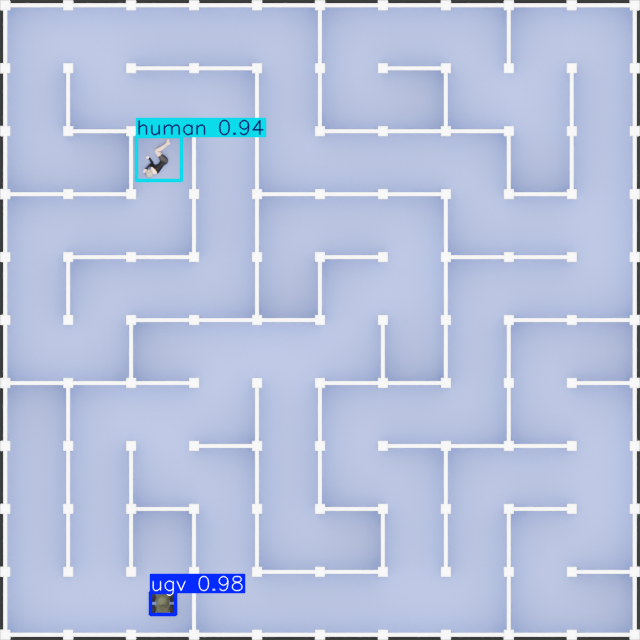



--- maze_env_0930.png ---


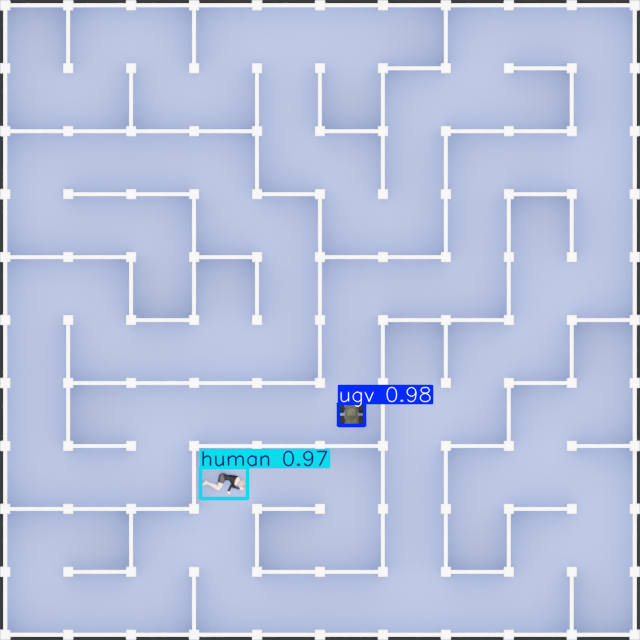



--- maze_env_0827.png ---


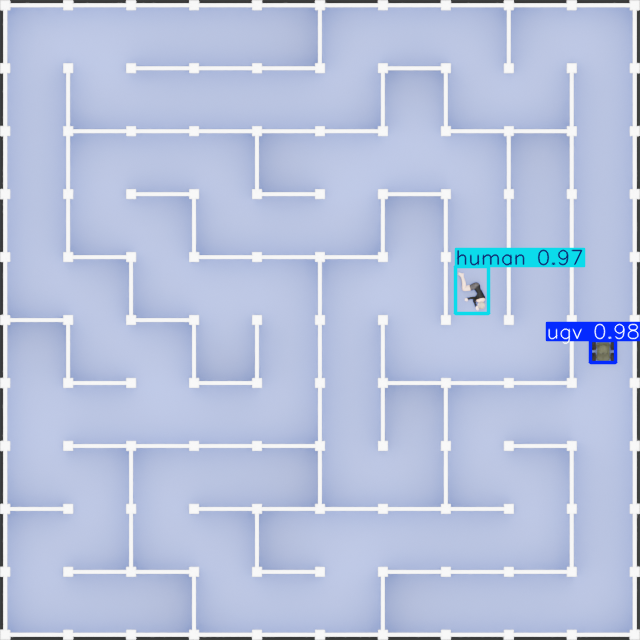



--- maze_env_0528.png ---


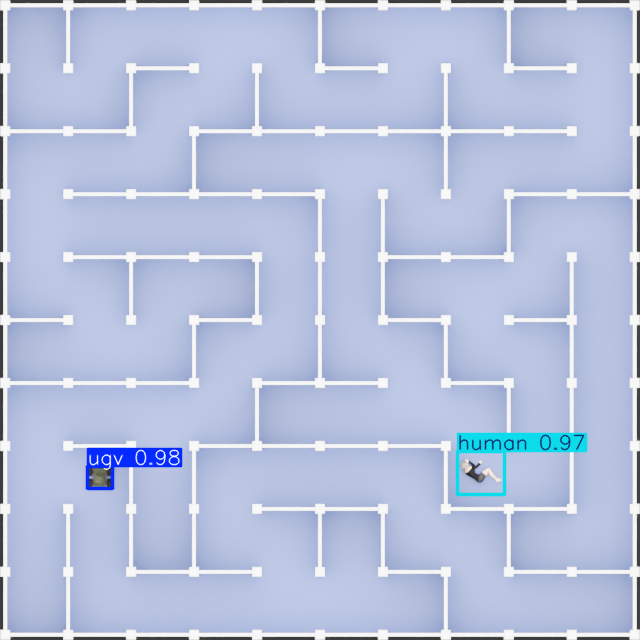



--- maze_env_0494.png ---


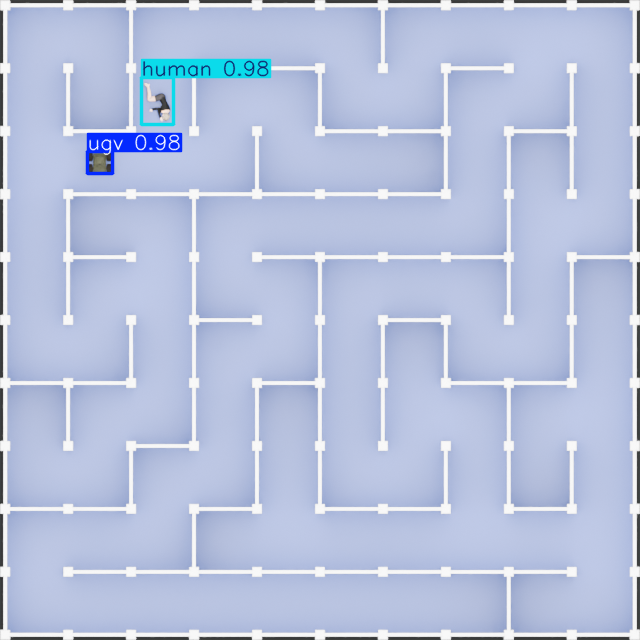

In [7]:
# Test the model
import glob
import random
from IPython.display import Image, display

weight_path = '/content/gdrive/MyDrive/Colab Notebooks/overhead-sar-navigation/object_detection/runs/maze_actor_detection_v1/weights/best.pt'
detection_model = YOLO(weight_path)

# There are 100 test images to choose from
all_test_images = glob.glob('/content/synthetic_dataset/images/test/*.png')
random_sequence = random.sample(all_test_images, 5)
output_dir = '/content/test_runs'

# Run prediction on the list
for img_path in random_sequence:
  original_name = os.path.basename(img_path)

  # Run prediction but do NOT auto-save to avoid .jpg
  results = detection_model.predict(source=img_path, save=False, verbose=False)

  # Force save as .png
  save_path = os.path.join(output_dir, original_name)
  results[0].save(filename=save_path)

  # Display results
  print(f"--- {original_name} ---")
  display(Image(filename=save_path, width=800))
  print("\n")